# Import modules

In [1]:
import numpy as np
import pandas as pd
from pipedream_solver.hydraulics import SuperLink
from pipedream_solver.simulation import Simulation
from pipedream_solver.diagnostics import PerformanceTracker
from pipedream_solver.ngeometry import Trapezoidal_A_ik, Trapezoidal_Pe_ik, Trapezoidal_B_ik
from swmm_boundary_conditions import normal_depth, critical_depth
import matplotlib.pyplot as plt
import seaborn as sns

# Scenario

This test notebook implements the EXTRAN1 test case from the EPA SWMM _Quality Assurance Report for Dynamic Wave Flow Routing_

> https://www.epa.gov/water-research/storm-water-management-model-swmm

# Read input data

In [2]:
scenario = 'extran1'
input_path = f'../data/{scenario}'
superjunctions = pd.read_csv(f'{input_path}/{scenario}__superjunctions.csv', index_col=0)
superlinks = pd.read_csv(f'{input_path}/{scenario}__superlinks.csv', index_col=0)
weirs = pd.read_csv(f'{input_path}/{scenario}__weirs.csv', index_col=0)
Q_in = pd.read_csv(f'{input_path}/{scenario}__Q_j.csv', index_col=0)

swmm_node_heads = pd.read_csv(f'{input_path}/{scenario}__SWMM_node_heads.csv', index_col=0)
swmm_link_flows = pd.read_csv(f'{input_path}/{scenario}__SWMM_link_flows.csv', index_col=0)

# Instantiate model

In [3]:
# Simulation parameters
dt = 20
internal_links = 4
num_iter = 500
spinup_steps = 1
t_start = 0
t_end = 8 * 3600
start_timestamp = pd.to_datetime('2002-01-01 00:00:00')

# Instantiate model
model = SuperLink(superlinks, superjunctions, weirs=weirs,
                  internal_links=internal_links)

# Weir control signal (set open)
u_w = np.ones(len(weirs), dtype=np.float64)

# Set bottom slopes at terminal links to zero
model._S_o_uk.fill(0.)
model._S_o_dk.fill(0.)

# Spin up model
model.spinup(n_steps=spinup_steps)

# Initialize volume for mass balance tracking
model.volume_tracker.set_init_volume()

# Add run-time performance tracker
performance_tracker = PerformanceTracker(model)
model.bind_callback(performance_tracker, 'performance_tracker')
model.performance_tracker = performance_tracker

# Set parameters for Newton iterations
model.convergence_tracker.max_learning_rate = 0.5
model.convergence_tracker.beta = 2.

# Variables needed to compute critical/normal depth
k = np.flatnonzero(np.isin(model._J_dk, np.flatnonzero(model.bc))).item()
sel = model._ki == k
S_o = model._S_o_ik[sel].mean()
n = model._n_ik[sel].mean()
g1 = model._g1_ik[sel].mean()
g2 = model._g2_ik[sel].mean()
g3 = model._g3_ik[sel].mean()

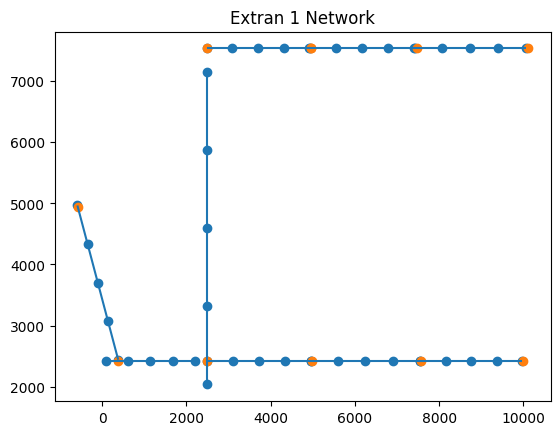

In [4]:
fig, ax = plt.subplots()
_ = model.plot_network_2d(ax=ax, weir_kwargs={'alpha' : 0})
_ = plt.title('Extran 1 Network')

# Run simulation

In [5]:
# Create dictionaries to store diagnostic information
iterations_elapsed = {}
convergence_queues = {}
learning_queues = {}
error_queues = {}
volume_in_system = {}
volume_net_added = {}
step_time_taken = {}

In [6]:
# Create simulation context manager
with Simulation(model, Q_in=Q_in, t_start=t_start, t_end=t_end) as simulation:
    # While simulation time has not expired...
    while simulation.t <= simulation.t_end:
        # Compute downstream boundary condition
        Q_bc = model._Q_ik[sel].mean()
        h_n = normal_depth(Trapezoidal_A_ik, Trapezoidal_Pe_ik, Q_bc, n, S_o, g1, g2, g3)
        h_c = critical_depth(Trapezoidal_A_ik, Trapezoidal_B_ik, Q_bc, g1, g2, g3)
        h_bc = min(h_n, h_c)
        H_bc = np.where(model.bc, model._z_inv_j + h_bc, 0.)
        # Step model forward in time
        simulation.step(dt=dt, H_bc=H_bc, u_w=u_w, num_iter=num_iter)
        # Record internal depth and flow states
        simulation.record_state()
        simulation.print_progress()
        # Store diagnostic metrics
        iterations_elapsed[simulation.t] = model.iter_elapsed
        convergence_queues[simulation.t] = model.convergence_tracker.convergence_queue
        error_queues[simulation.t] = model.convergence_tracker.error_queue
        learning_queues[simulation.t] = model.convergence_tracker.learning_queue
        volume_in_system[simulation.t] = model.volume_tracker.total_volume
        volume_net_added[simulation.t] = model.volume_tracker.cumulative_volume_flux
        step_time_taken[simulation.t] = model.performance_tracker.step_time_elapsed

[==================================================] 100.0% [5.91 s]

# Plot time series of states

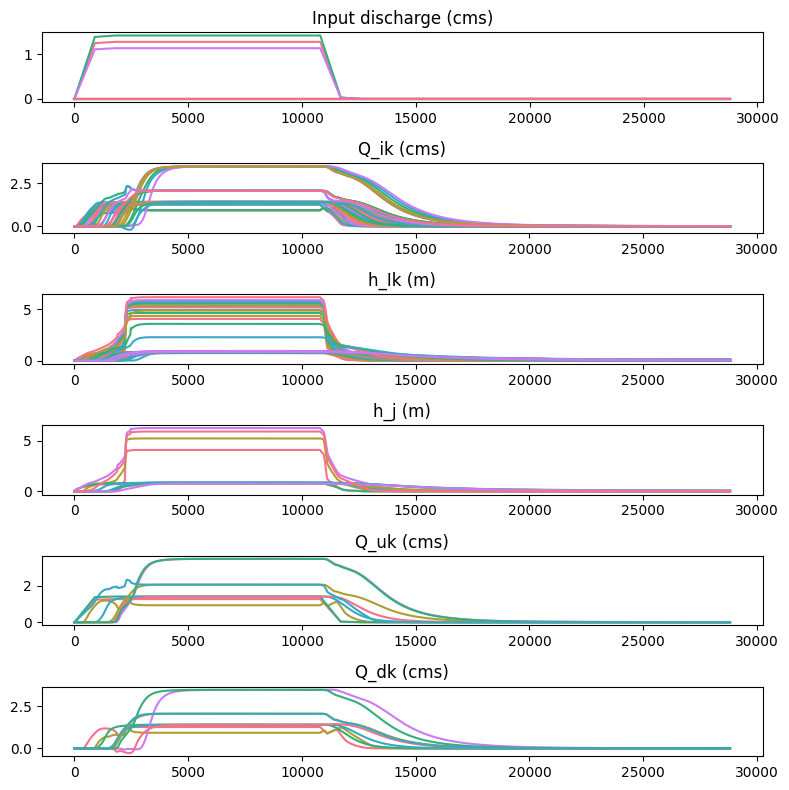

In [7]:
# Instantiate plot
sns.set_palette('husl', internal_links + 1)
fig, ax = plt.subplots(6, figsize=(8, 8))

# Plot results
simulation.Q_in.plot(ax=ax[0], title='Input discharge (cms)', legend=False)
simulation.states.Q_ik.plot(ax=ax[1], title='Q_ik (cms)', legend=False)
simulation.states.h_Ik.plot(ax=ax[2], title='h_Ik (m)', legend=False)
(simulation.states.H_j - model._z_inv_j).plot(ax=ax[3], title='h_j (m)', legend=False)
simulation.states.Q_uk.plot(ax=ax[4], title='Q_uk (cms)', legend=False)
simulation.states.Q_dk.plot(ax=ax[5], title='Q_dk (cms)', legend=False)

# Configure plots
plt.tight_layout()


# Comparison against SWMM outputs

In [8]:
H_j = simulation.states.H_j.copy()
H_j.index = pd.to_timedelta(H_j.index, unit='s') + start_timestamp
Q_ik = simulation.states.Q_ik.copy()
Q_ik.index = pd.to_timedelta(Q_ik.index, unit='s') + start_timestamp

swmm_node_heads.index = pd.to_datetime(swmm_node_heads.index)
swmm_link_flows.index = pd.to_datetime(swmm_link_flows.index)

#### Compare against computed SWMM heads

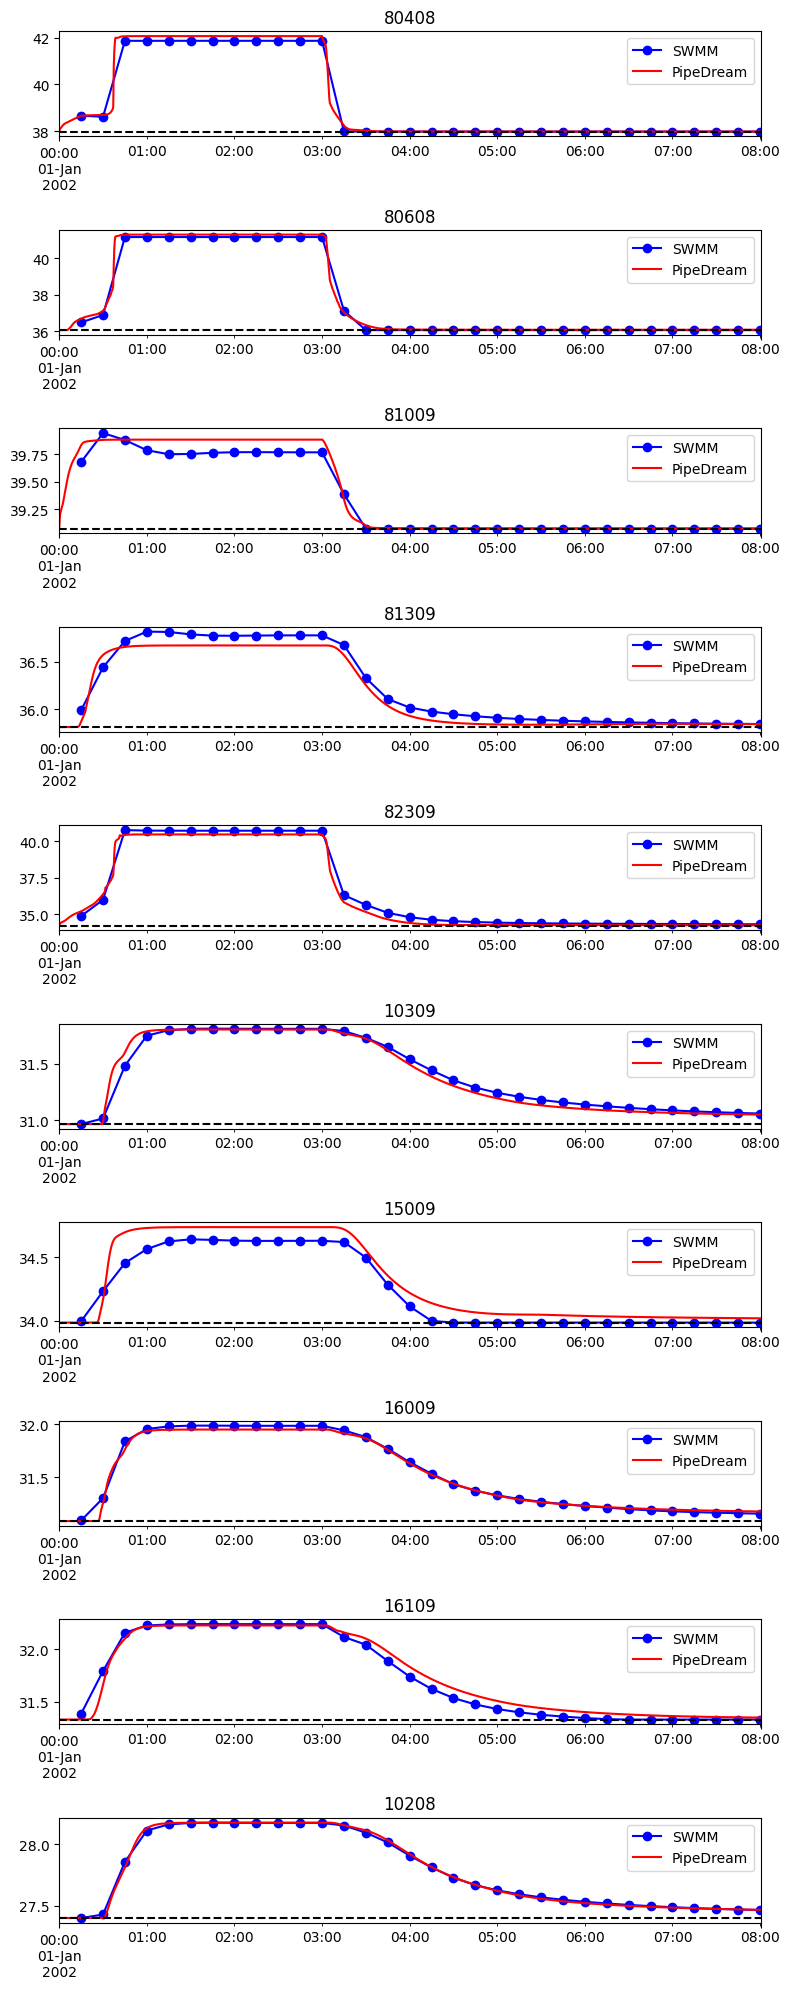

In [9]:
fig, ax = plt.subplots(len(swmm_node_heads.columns), figsize=(8, 20))
for i, index in enumerate(swmm_node_heads.columns):
    swmm_node_heads[index].plot(ax=ax[i], label='SWMM', marker='o', c='b')
    H_j[index].plot(ax=ax[i], label='PipeDream', c='r')
    j = model.superjunctions.set_index('name').loc[index, 'id']
    ax[i].axhline(model._z_inv_j[j], linestyle='--', c='k')
    ax[i].set_title(index)
    ax[i].legend()
plt.tight_layout()

#### Compare against computed SWMM flows

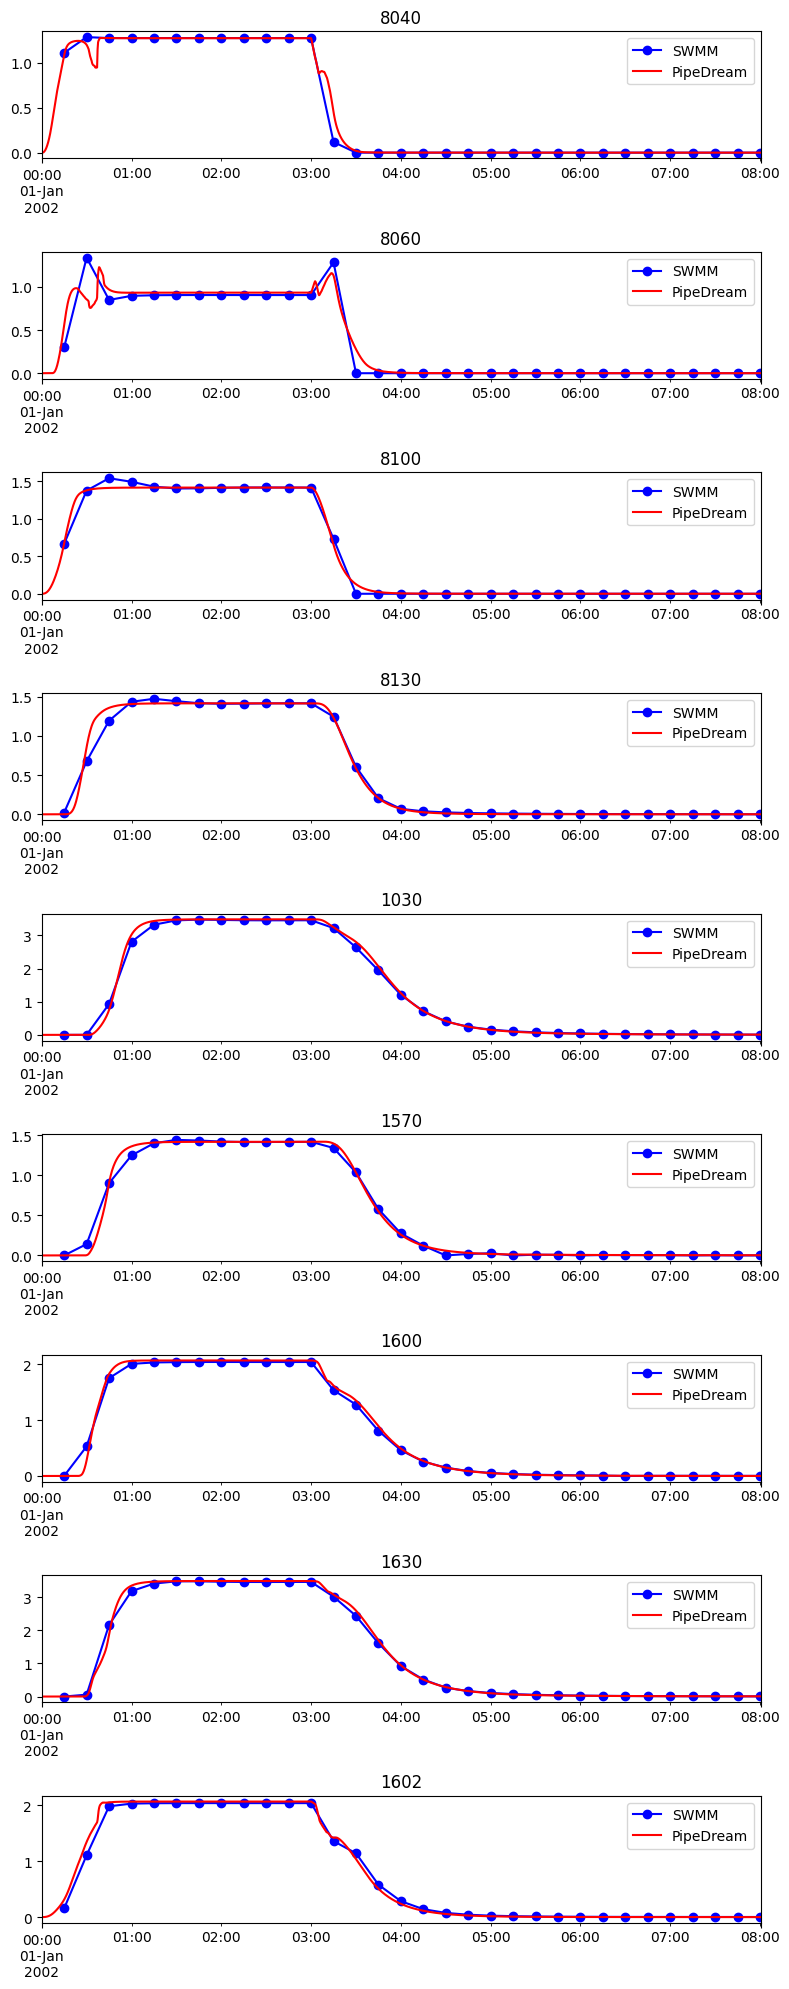

In [10]:
fig, ax = plt.subplots(len(swmm_link_flows.columns), figsize=(8, 20))
for i, index in enumerate(swmm_link_flows.columns):
    junctions = np.flatnonzero(model._ki == model.superlinks.reset_index().set_index('name').loc[int(index), 'index'])
    swmm_link_flows[index].plot(ax=ax[i], label='SWMM', marker='o', c='b')
    Q_ik[junctions].mean(axis=1).plot(ax=ax[i], label='PipeDream', c='r')
    ax[i].set_title(index)
    ax[i].legend()
plt.tight_layout()


# Mass balance analysis

In [11]:
# Overflow weir outflow to boundary point
Q_w_out = (simulation.states.Q_w.iloc[:, :-1].sum(axis=1) * simulation.states.Q_w.index.diff()).fillna(0.)

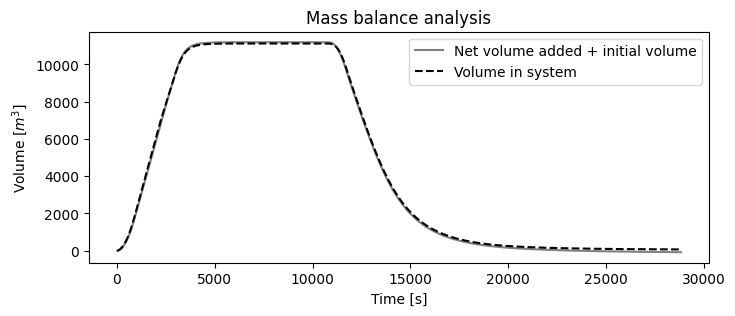

In [12]:
fig, ax = plt.subplots(figsize=(8, 3))
(pd.Series(volume_net_added) + model.volume_tracker.init_volume - Q_w_out.cumsum()).plot(ax=ax, label='Net volume added + initial volume', c='0.5')
pd.Series(volume_in_system).plot(ax=ax, label='Volume in system', c='k', linestyle='--')
plt.xlabel('Time [s]')
plt.ylabel('Volume [$m^3$]')
plt.title('Mass balance analysis')
_ = plt.legend()

# Convergence analysis

#### Step convergence criterion $||x_{new} - x_{old}||_\infty$

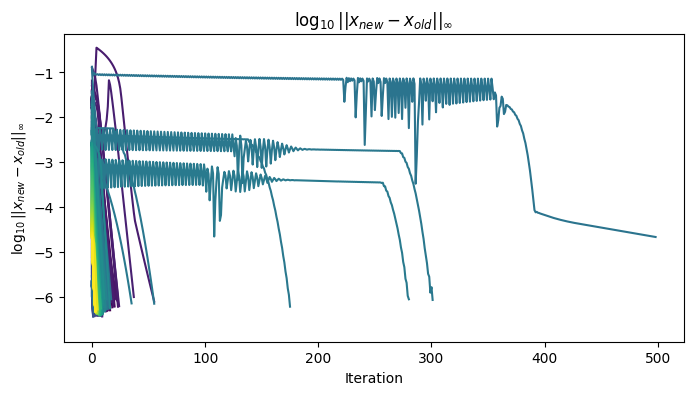

In [13]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in convergence_queues:
    ax.plot(np.log10(np.asarray(convergence_queues[key])))
_ = plt.title('$\log_{10} ||x_{new} - x_{old}||_\infty$')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('$\log_{10} ||x_{new} - x_{old}||_\infty$')

### Error convergence criterion $||f(x)||_\infty$

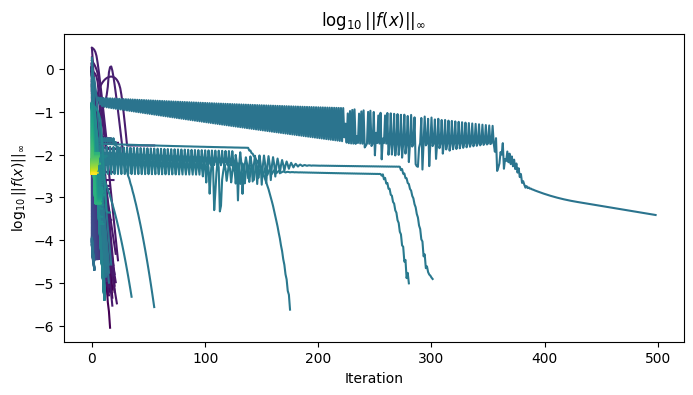

In [14]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in error_queues:
    ax.plot(np.log10(np.array(error_queues[key])))
_ = plt.title('$\log_{10} ||f(x)||_\infty$')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('$\log_{10} ||f(x)||_\infty$')


### Newton step size

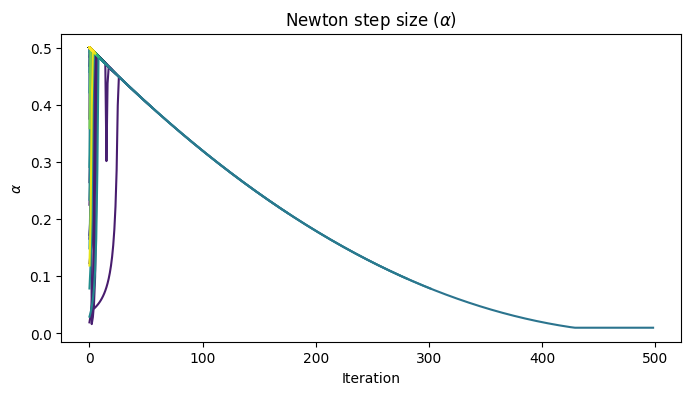

In [15]:
sns.set_palette('viridis', len(convergence_queues))
fig, ax = plt.subplots(figsize=(8, 4))
for key in learning_queues:
    ax.plot(np.array(learning_queues[key]))
_ = plt.title('Newton step size ($\\alpha$)')
_ = plt.xlabel('Iteration')
_ = plt.ylabel('$\\alpha$')


### Number of iterations elapsed

Text(0, 0.5, 'Iterations')

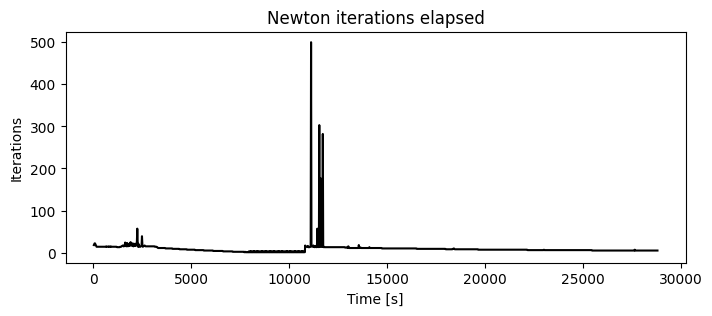

In [16]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.Series(iterations_elapsed).plot(ax=ax, c='k')
plt.title('Newton iterations elapsed')
plt.xlabel('Time [s]')
plt.ylabel('Iterations')

### Simulation time elapsed

Text(0, 0.5, 'Clock time elapsed [s]')

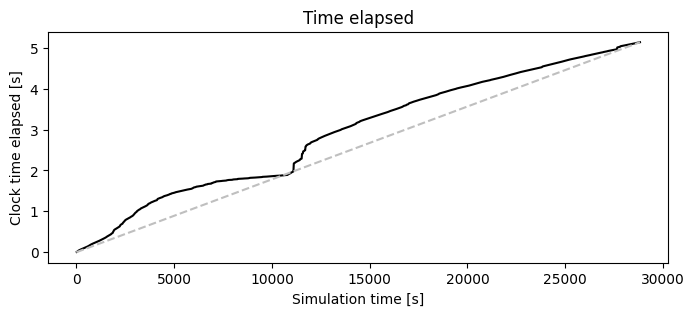

In [17]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.Series(step_time_taken).cumsum().plot(ax=ax, c='k')
plt.plot([0, simulation.t], [0, pd.Series(step_time_taken).cumsum().iloc[-1]], c='0.75', linestyle='--')
plt.title('Time elapsed')
plt.xlabel('Simulation time [s]')
plt.ylabel('Clock time elapsed [s]')